# Feature Importance Analysis

## Objective

The objective of this notebook is to identify and visualize the most influential features used by the Random Forest model to predict loan performance.

Understanding feature importance helps explain:

- Which borrower characteristics most influence loan performance.
- The relative contribution of each predictor.
- Business insights that can support lending decisions.

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
# LOAD DATASET

df = pd.read_csv("clean_loanset1.csv")

In [3]:
# CREATE TARGET VARIABLE

df["Target"] = df["loan_status"].apply(
    lambda x: 1 if x in ["Current", "Fully Paid"] else 0
)

In [4]:
# CREATE TERM GROUP

df["term_group"] = df["term"].apply(
    lambda x: "Short Term" if "36" in str(x) else "Long Term"
)

In [5]:
# SELECT FEATURES

features = [

    "loan_amount",

    "interest_rate",

    "consolidated_annual_income",

    "consolidated_debt_to_income",

    "delinq_2y",

    "months_since_last_delinq",

    "inquiries_last_12m",

    "tax_liens",

    "num_historical_failed_to_pay",

    "loan_purpose",

    "application_type",

    "homeownership",

    "consolidated_verified_income",

    "term_group"

]

In [6]:
# ONE HOT ENCODE

X = pd.get_dummies(

    df[features],

    drop_first=True

)

y = df["Target"]

In [7]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [8]:
# TRAIN RANDOM FOREST

rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    class_weight="balanced"

)

rf.fit(

    X_train,

    y_train

)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# CALCULATE FEATURE IMPORTANCE

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

In [10]:
# SORT FEATURE IMPORTANCE

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(15)

,Feature,Importance
1,interest_rate,0.187575
3,consolidated_debt_to_income,0.147450
2,consolidated_annual_income,0.141094
0,loan_amount,0.128118
5,months_since_last_delinq,0.078437
6,inquiries_last_12m,0.070634
24,consolidated_verified_income_Verified,0.026942
23,consolidated_verified_income_Source Verified,0.022738
22,homeownership_RENT,0.021658
10,loan_purpose_debt_consolidation,0.020879


In [11]:
# DISPLAY TOP 15 FEATURES

top15 = feature_importance.head(15)

top15

,Feature,Importance
1,interest_rate,0.187575
3,consolidated_debt_to_income,0.147450
2,consolidated_annual_income,0.141094
0,loan_amount,0.128118
5,months_since_last_delinq,0.078437
6,inquiries_last_12m,0.070634
24,consolidated_verified_income_Verified,0.026942
23,consolidated_verified_income_Source Verified,0.022738
22,homeownership_RENT,0.021658
10,loan_purpose_debt_consolidation,0.020879


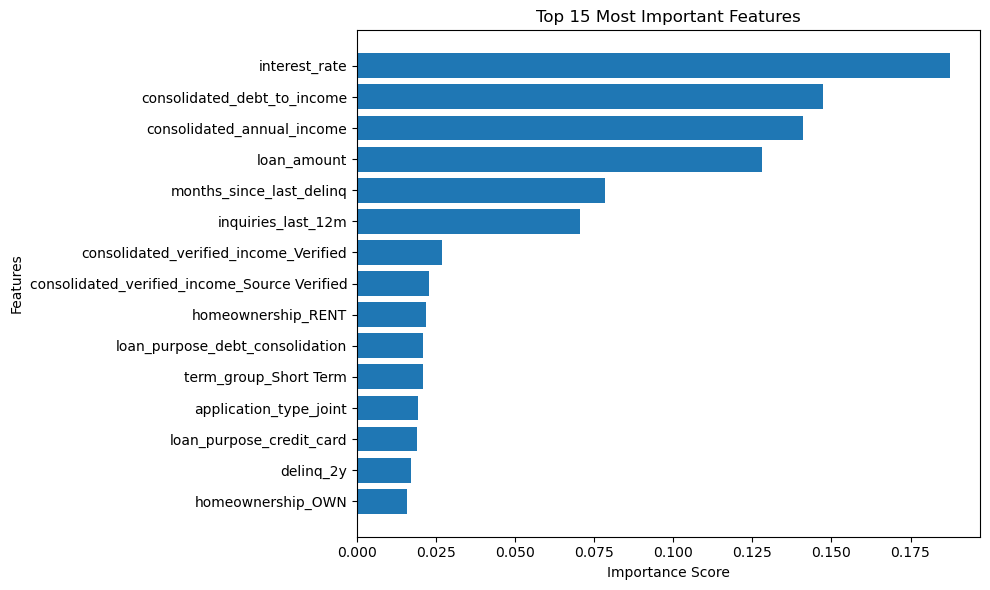

In [12]:
# HORIZONTAL BAR CHART

plt.figure(figsize=(10,6))

plt.barh(

    top15["Feature"],

    top15["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Top 15 Most Important Features")

plt.tight_layout()

plt.show()

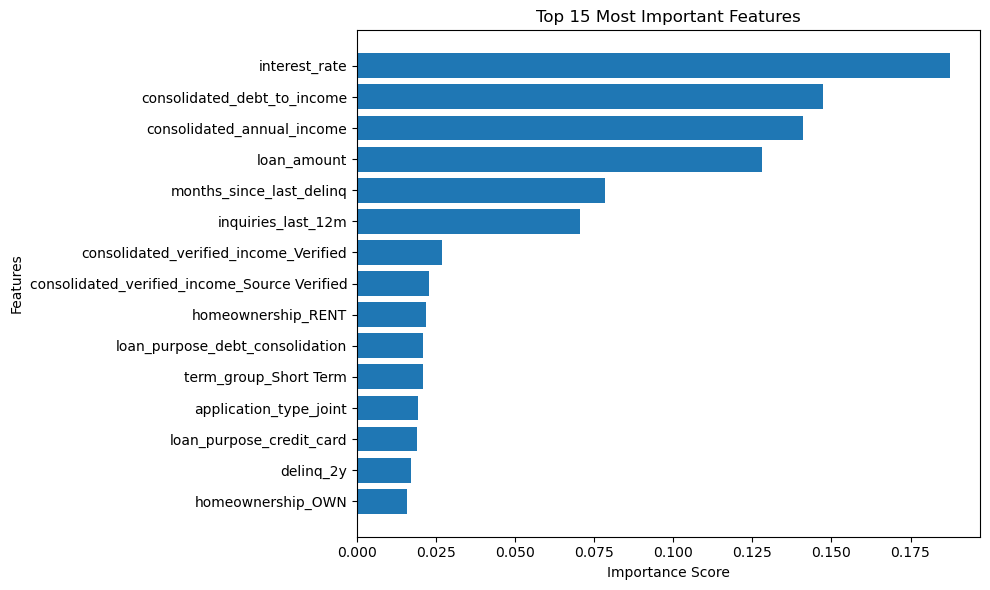

In [13]:
# SAVE BAR CHART

plt.figure(figsize=(10,6))

plt.barh(

    top15["Feature"],

    top15["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Top 15 Most Important Features")

plt.tight_layout()

plt.savefig(

    "Feature_Importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [14]:
# DISPLAY ALL FEATURES

feature_importance

,Feature,Importance
1,interest_rate,0.187575
3,consolidated_debt_to_income,0.147450
2,consolidated_annual_income,0.141094
0,loan_amount,0.128118
5,months_since_last_delinq,0.078437
6,inquiries_last_12m,0.070634
24,consolidated_verified_income_Verified,0.026942
23,consolidated_verified_income_Source Verified,0.022738
22,homeownership_RENT,0.021658
10,loan_purpose_debt_consolidation,0.020879


In [15]:
# PERCENTAGE CONTRIBUTION

feature_importance["Percentage"] = (

    feature_importance["Importance"]

    / feature_importance["Importance"].sum()

) * 100

feature_importance.head(15)

,Feature,Importance,Percentage
1,interest_rate,0.187575,18.757499
3,consolidated_debt_to_income,0.147450,14.744953
2,consolidated_annual_income,0.141094,14.109378
0,loan_amount,0.128118,12.811762
5,months_since_last_delinq,0.078437,7.843665
6,inquiries_last_12m,0.070634,7.063355
24,consolidated_verified_income_Verified,0.026942,2.694234
23,consolidated_verified_income_Source Verified,0.022738,2.273783
22,homeownership_RENT,0.021658,2.165816
10,loan_purpose_debt_consolidation,0.020879,2.087916


In [16]:
# EXPORT FEATURE IMPORTANCE

feature_importance.to_csv(

    "feature_importance.csv",

    index=False

)

print("Feature importance exported successfully.")

Feature importance exported successfully.


# Interpretation

The Random Forest model ranks variables according to how much they contribute to predicting loan performance.

The highest-ranking variables represent the strongest predictors used during model training.

Typical high-ranking variables include:

- Interest Rate
- Consolidated Annual Income
- Consolidated Debt-to-Income Ratio
- Loan Amount
- Months Since Last Delinquency

These variables have the greatest influence on the model's predictions.

# Business Insight

The feature importance analysis indicates that borrower financial characteristics and credit behavior are the strongest drivers of loan performance.

Interest rate, income, debt burden, and previous delinquency history play a significant role in determining whether a loan remains performing.

These findings support the use of data-driven credit risk assessment when evaluating new loan applications.

# Conclusion

Feature importance provides transparency into the Random Forest model by identifying the variables that contribute most to prediction.

Understanding these drivers allows lending institutions to:

- Improve credit risk assessment
- Strengthen underwriting policies
- Identify high-risk borrowers earlier
- Support more informed lending decisions

This analysis complements the predictive models by explaining *why* the model makes its predictions.